# **SpaceX  Falcon 9 First Stage Landing Prediction**


## Assignment: Exploring and Preparing Data

In this assignment, we will predict if the Falcon 9 first stage will land successfully. SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is due to the fact that SpaceX can reuse the first stage.

In this lab, you will perform Exploratory Data Analysis and Feature Engineering.


Falcon 9 first stage will land successfully

![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:

![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)

## Objectives

Perform exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`

*   Exploratory Data Analysis
*   Preparing Data  Feature Engineering

### Import Libraries and Define Auxiliary Functions

We will import the following libraries the lab

In [1]:
# pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

## Exploratory Data Analysis


In [2]:
URL= 'C:/Users/MARCELA JAIMES/Documents/D/DataScienceIBM/dataset_part_2.csv'
df=pd.read_csv(URL)
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [ ]:
Launch_Sites = 

First, let's try to see how the `FlightNumber` (indicating the continuous launch attempts.) and `Payload` variables would affect the launch outcome.

We can plot out the <code>FlightNumber</code> vs. <code>PayloadMass</code>and overlay the outcome of the launch. We see that as the flight number increases, the first stage is more likely to land successfully. The payload mass also appears to be a factor; even with more massive payloads, the first stage often returns successfully.

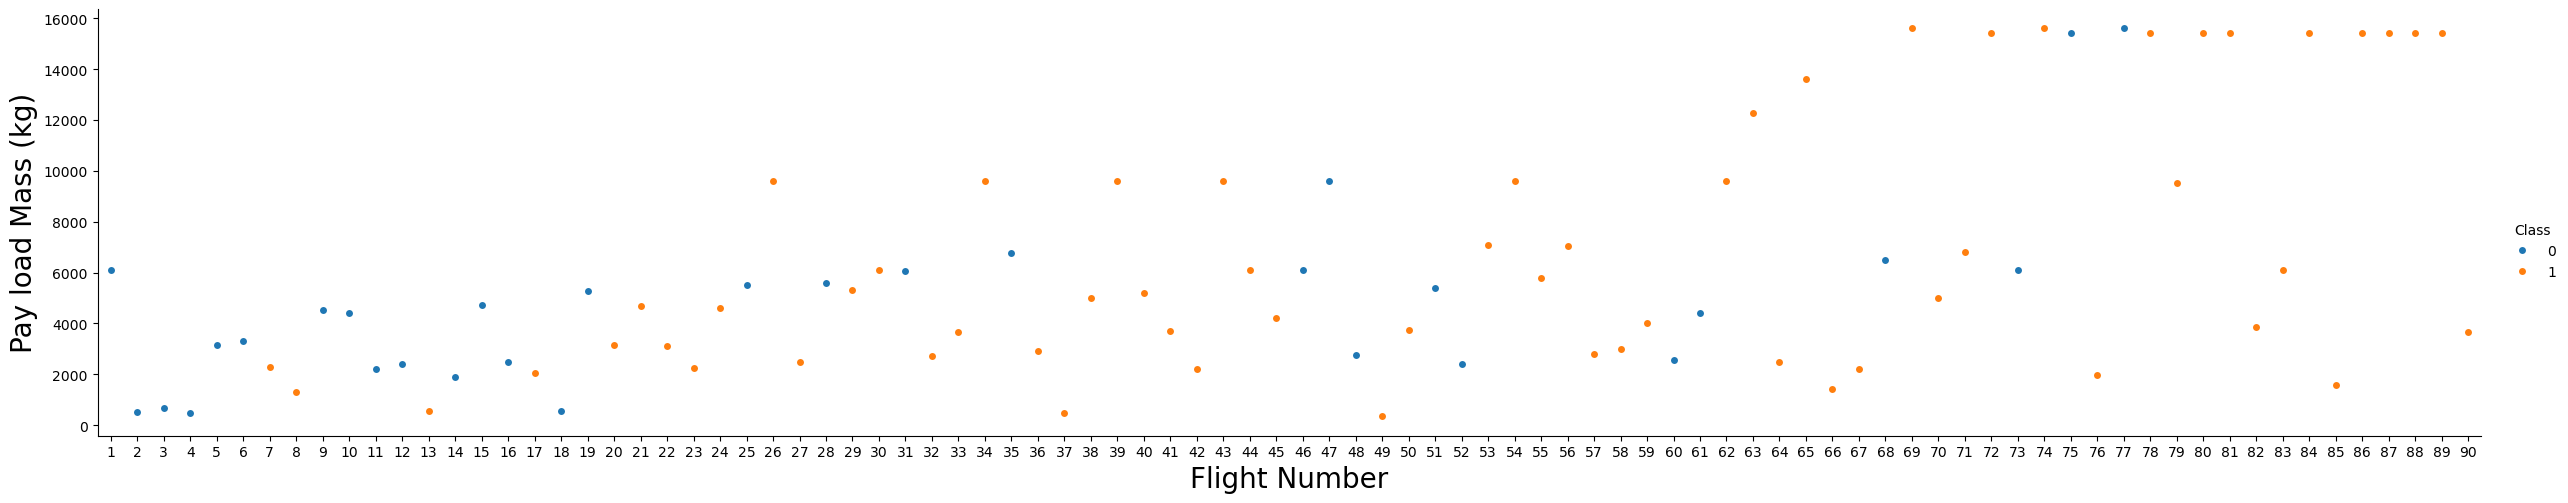

In [3]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

Next, let's drill down to each site and visualize its detailed launch records.

### TASK 1: Visualize the relationship between Flight Number and Launch Site

Use the function <code>catplot</code> to plot <code>FlightNumber</code> vs <code>LaunchSite</code>, set the  parameter <code>x</code>  parameter to <code>FlightNumber</code>,set the  <code>y</code> to <code>Launch Site</code> and set the parameter <code>hue</code> to <code>'class'</code>


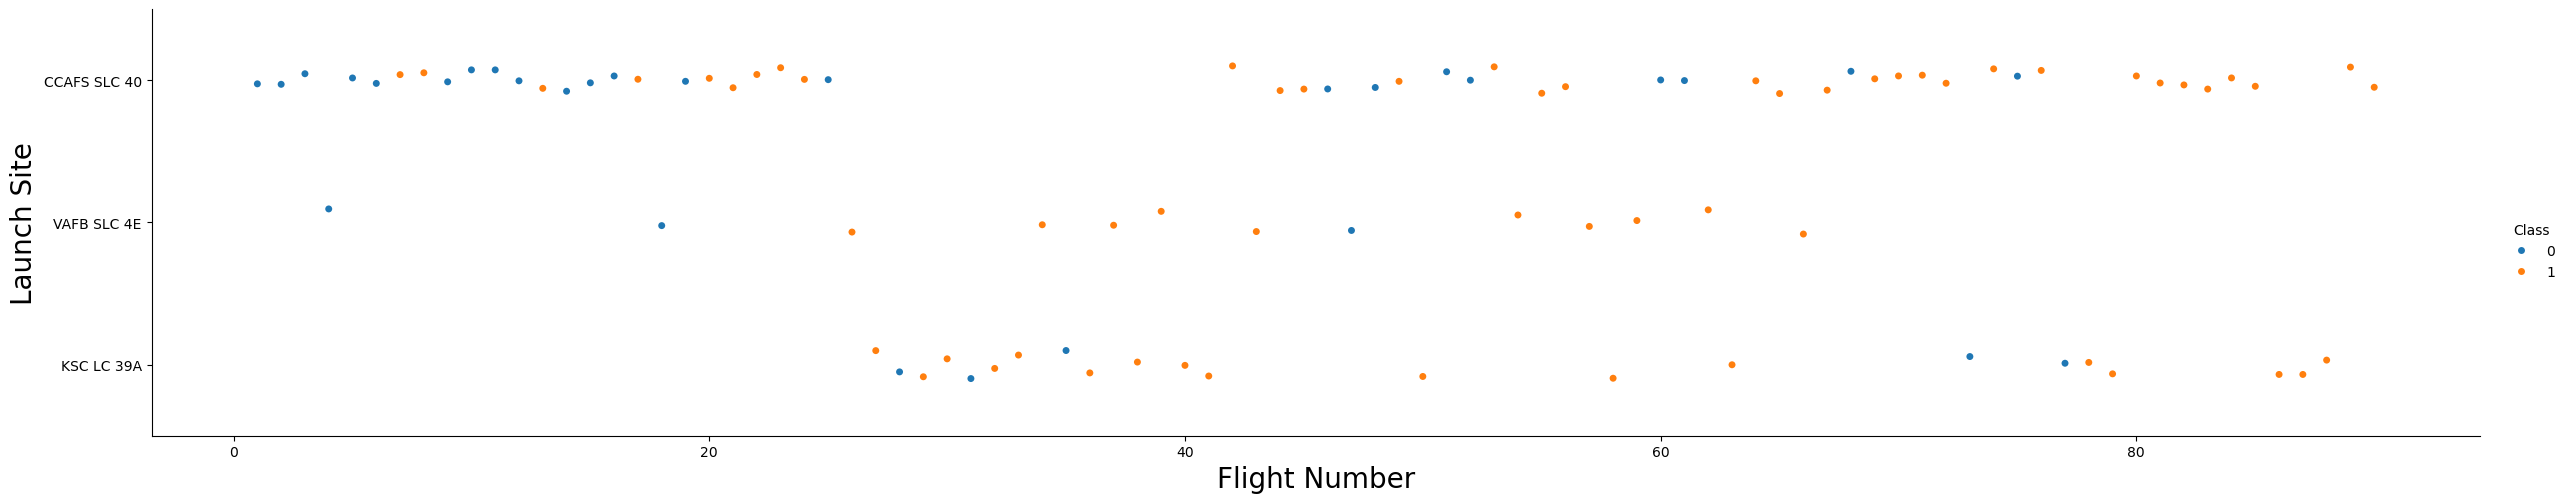

In [4]:
sns.catplot(x='FlightNumber', y='LaunchSite', hue='Class', data=df, aspect=5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Launch Site",fontsize=20)
plt.show()

Now try to explain the patterns you found in the Flight Number vs. Launch Site scatter point plots.

### TASK 2: Visualize the relationship between Payload Mass and Launch Site

We also want to observe if there is any relationship between launch sites and their payload mass.

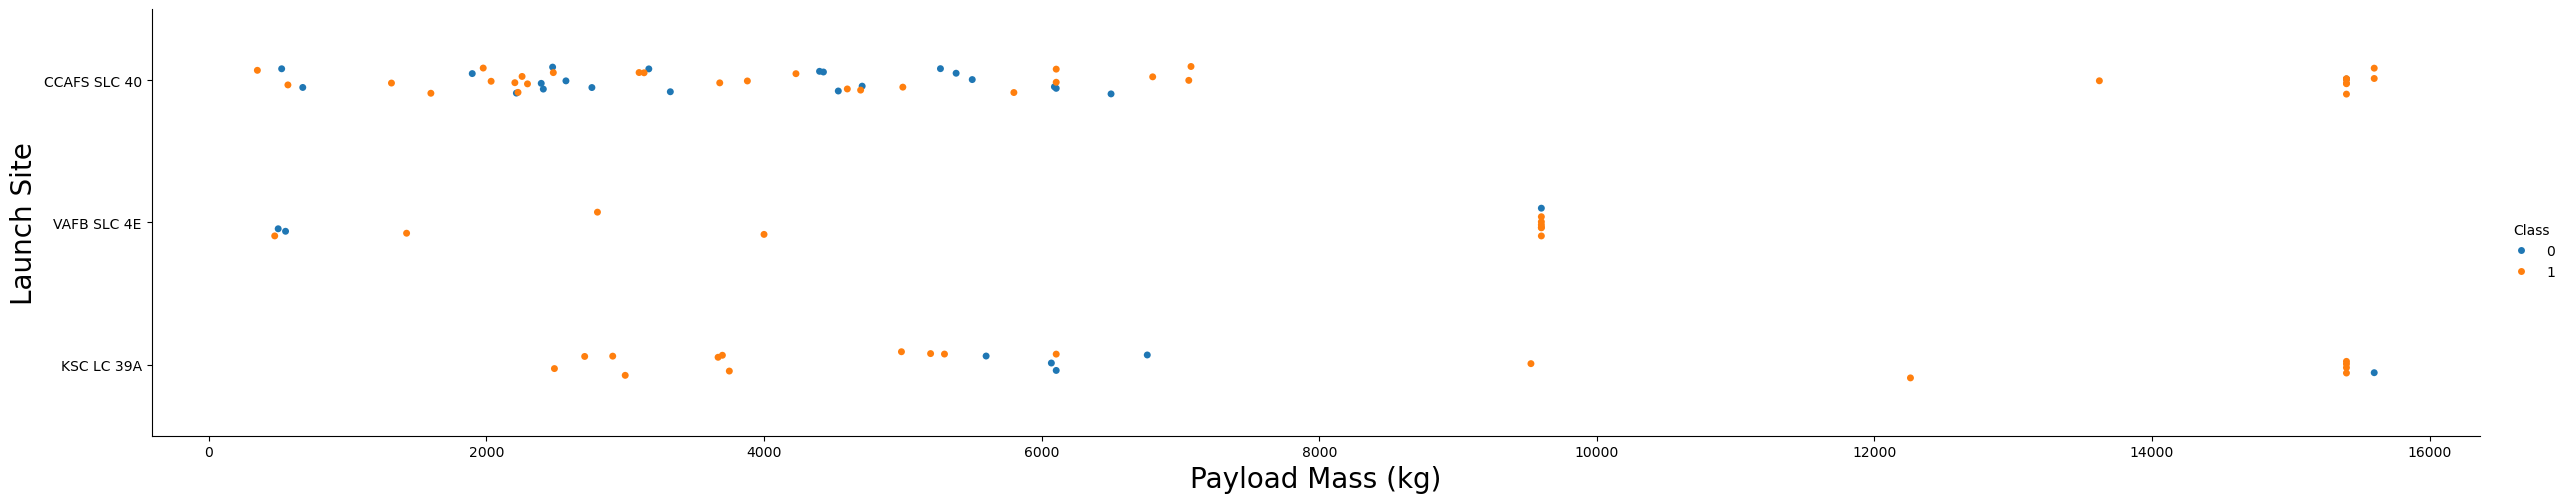

In [5]:
# Plot a scatter point chart with x axis to be Pay Load Mass (kg) and y axis to be the launch site, and hue to be the class value
sns.catplot(x= 'PayloadMass', y = 'LaunchSite', hue= "Class", data=df, aspect=5)
plt.xlabel("Payload Mass (kg)",fontsize=20)
plt.ylabel("Launch Site",fontsize=20)
plt.show()

Now if you observe Payload Mass Vs. Launch Site scatter point chart you will find for the VAFB-SLC  launchsite there are no  rockets  launched for  heavypayload mass(greater than 10000).

### TASK  3: Visualize the relationship between success rate of each orbit type

Next, we want to visually check if there are any relationship between success rate and orbit type.

Let's create a `bar chart` for the sucess rate of each orbit

In [6]:
df_total_launches_orbit = df.groupby("Orbit")["Class"].count().reset_index()
df_total_launches_orbit.rename(columns={"Class": "Total_Launches"}, inplace=True)
df_total_launches_orbit.head()


,Orbit,Total_Launches
0,ES-L1,1
1,GEO,1
2,GTO,27
3,HEO,1
4,ISS,21


In [7]:
df_success_vs_orbit = df.groupby('Orbit')['Class'].sum().reset_index()
df_success_vs_orbit.rename(columns={"Class":"Total_Success"}, inplace=True)
df_success_vs_orbit.head()


,Orbit,Total_Success
0,ES-L1,1
1,GEO,1
2,GTO,14
3,HEO,1
4,ISS,13


In [8]:
df_rate_success_orbit= df_total_launches_orbit.merge(
    df_success_vs_orbit,
    on = "Orbit",
    how = "left"
)
df_rate_success_orbit["Total_Success"]=df_rate_success_orbit["Total_Success"].fillna(0)

df_rate_success_orbit["Success_Rate"] = (
    df_rate_success_orbit["Total_Success"] / df_rate_success_orbit["Total_Launches"]
)
df_rate_success_orbit.head()

,Orbit,Total_Launches,Total_Success,Success_Rate
0,ES-L1,1,1,1.000000
1,GEO,1,1,1.000000
2,GTO,27,14,0.518519
3,HEO,1,1,1.000000
4,ISS,21,13,0.619048


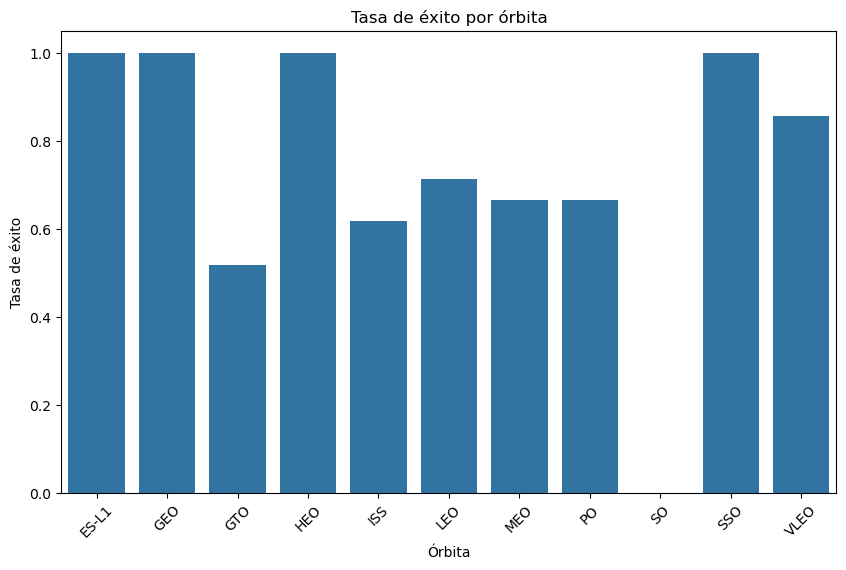

In [9]:
# Tamaño de la figura
plt.figure(figsize=(10,6))

# Gráfico de barras
sns.barplot(
    data=df_rate_success_orbit,
    x="Orbit",
    y="Success_Rate"
)

# Títulos y etiquetas
plt.title("Tasa de éxito por órbita")
plt.xlabel("Órbita")
plt.ylabel("Tasa de éxito")

# Rotar etiquetas si hay muchas órbitas
plt.xticks(rotation=45)

# Mostrar gráfico
plt.show()

### TASK  4: Visualize the relationship between FlightNumber and Orbit type

For each orbit, we want to see if there is any relationship between FlightNumber and Orbit type.

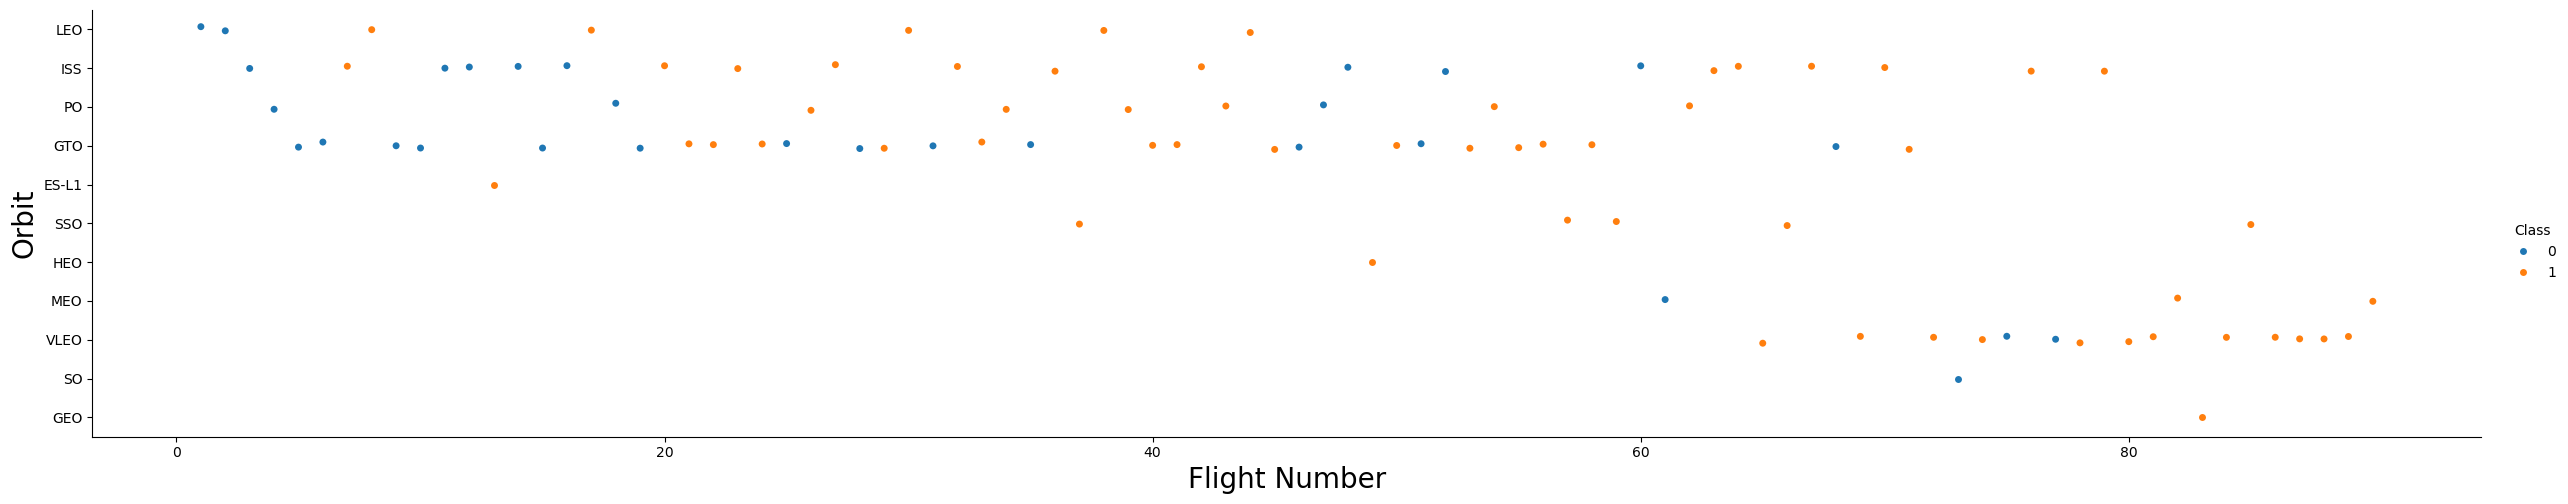

In [10]:
sns.catplot( x= "FlightNumber", y= "Orbit", hue = "Class", data= df, aspect= 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Orbit",fontsize=20)
plt.show()

You can observe that in the LEO orbit, success seems to be related to the number of flights. Conversely, in the GTO orbit, there appears to be no relationship between flight number and success.

### TASK  5: Visualize the relationship between Payload Mass and Orbit type

Similarly, we can plot the Payload Mass vs. Orbit scatter point charts to reveal the relationship between Payload Mass and Orbit type


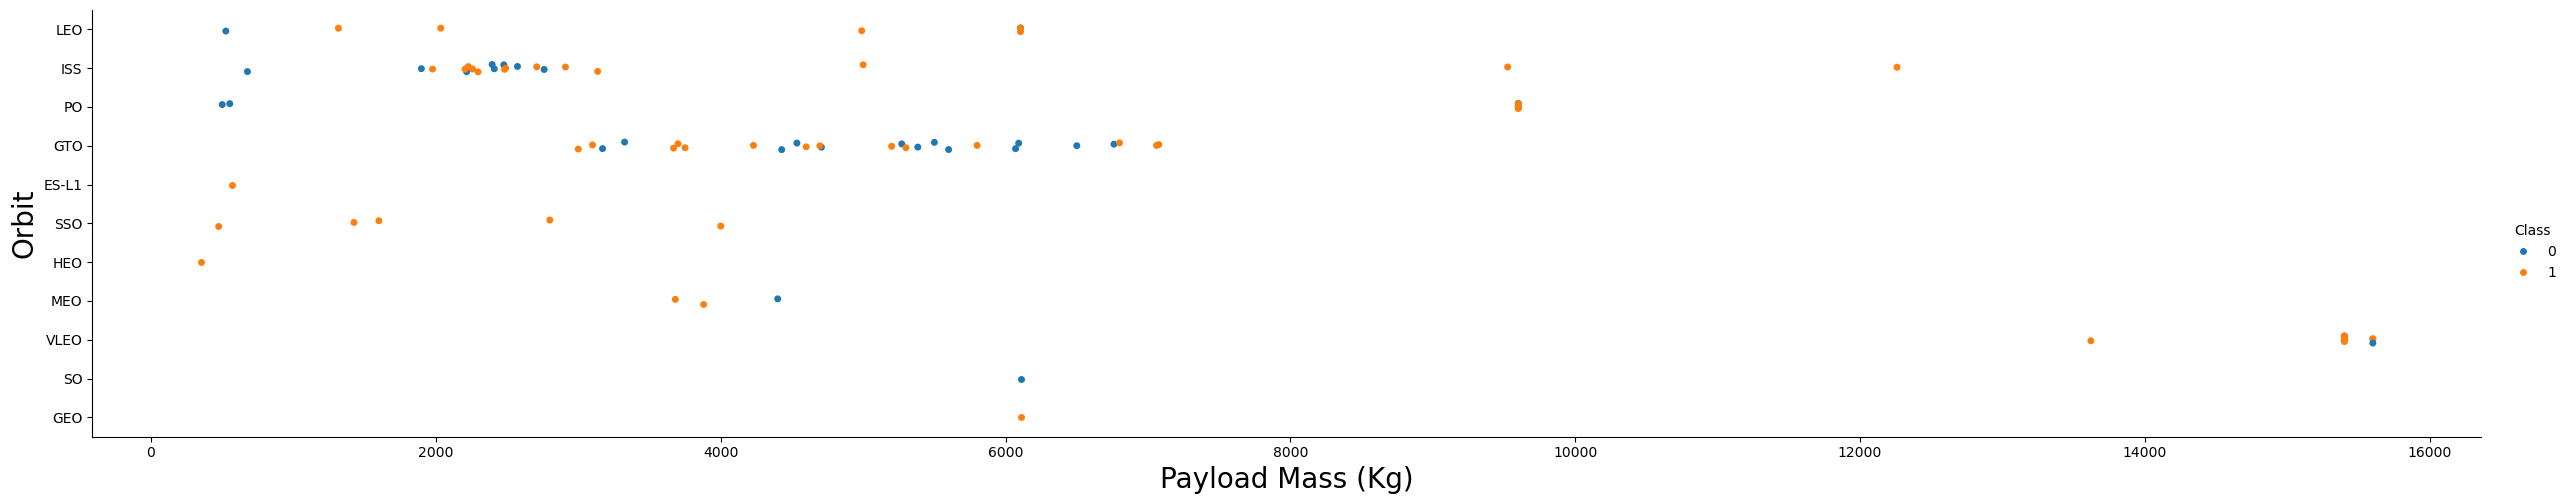

In [11]:
sns.catplot(x="PayloadMass", y="Orbit", hue="Class", data=df, aspect=5)
plt.xlabel("Payload Mass (Kg)", fontsize = 20)
plt.ylabel("Orbit",fontsize = 20)
plt.show()

With heavy payloads the successful landing or positive landing rate are more for Polar,LEO and ISS.

However, for GTO, it's difficult to distinguish between successful and unsuccessful landings as both outcomes are present.



### TASK  6: Visualize the launch success yearly trend

In [12]:
df["Date"] = pd.to_datetime(df["Date"])
df["Date"] = pd.to_datetime(df["Date"]).dt.year


In [13]:
df_total_launches_year = df.groupby("Date")["Class"].count().reset_index()
df_total_launches_year.rename(columns={"Class":"Total_Launches"}, inplace=True)
df_total_launches_year.head()

,Date,Total_Launches
0,2010,1
1,2012,1
2,2013,3
3,2014,6
4,2015,6


In [14]:
df_total_success_year = df.groupby("Date")["Class"].sum().reset_index()
df_total_success_year.rename(columns={"Class":"Total_Success"}, inplace=True)
df_total_success_year.head()

,Date,Total_Success
0,2010,0
1,2012,0
2,2013,0
3,2014,2
4,2015,2


In [15]:
df_rate_success_year= df_total_launches_year.merge( df_total_success_year, on= "Date", how="left")
df_rate_success_year["Success_Rate"]= (df_rate_success_year["Total_Success"]/df_rate_success_year["Total_Launches"]) 
df_rate_success_year.head()

,Date,Total_Launches,Total_Success,Success_Rate
0,2010,1,0,0.000000
1,2012,1,0,0.000000
2,2013,3,0,0.000000
3,2014,6,2,0.333333
4,2015,6,2,0.333333


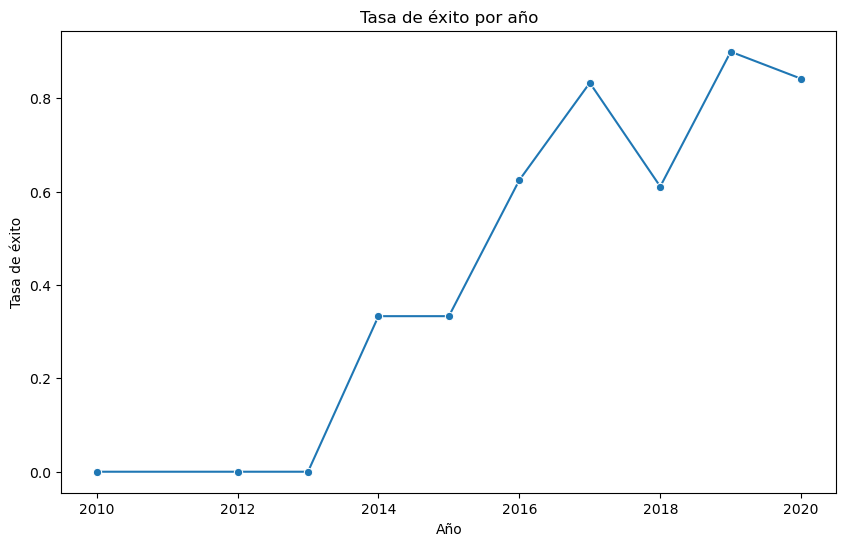

In [16]:
# Asegurar que esté ordenado por año
df_rate_success_year = df_rate_success_year.sort_values(by="Date")

# Crear figura
plt.figure(figsize=(10,6))

# Gráfico de línea
sns.lineplot(
    data=df_rate_success_year,
    x="Date",
    y="Success_Rate",
    marker="o"
)

# Títulos y etiquetas
plt.title("Tasa de éxito por año")
plt.xlabel("Año")
plt.ylabel("Tasa de éxito")

# Mostrar gráfico
plt.show()

you can observe that the sucess rate since 2013 kept increasing till 2020

## Features Engineering

By now, you should obtain some preliminary insights about how each important variable would affect the success rate, we will select the features that will be used in success prediction in the future module.

In [17]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


### TASK  7: Create dummy variables to categorical columns

Use the function <code>get_dummies</code> and <code>features</code> dataframe to apply OneHotEncoder to the column <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code>, and <code>Serial</code>. Assign the value to the variable <code>features_one_hot</code>, display the results using the method head. Your result dataframe must include all features including the encoded ones.

In [25]:
features_one_hot = pd.get_dummies(
    features,
    columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'],
    drop_first=True
)
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_GEO,Orbit_GTO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,True,...,False,False,False,False,False,False,False,False,False,False


In [28]:
features_one_hot.shape

(90, 76)

In [19]:
'''
label_encoder = LabelEncoder()

features['Orbit'] = label_encoder.fit_transform(features['Orbit']) 
features['LaunchSite'] = label_encoder.fit_transform(features['LaunchSite'])
features['LandingPad'] = label_encoder.fit_transform(features['LandingPad'])
features['Serial'] = label_encoder.fit_transform(features['Serial'])

features.head()
'''

"\nlabel_encoder = LabelEncoder()\n\nfeatures['Orbit'] = label_encoder.fit_transform(features['Orbit']) \nfeatures['LaunchSite'] = label_encoder.fit_transform(features['LaunchSite'])\nfeatures['LandingPad'] = label_encoder.fit_transform(features['LandingPad'])\nfeatures['Serial'] = label_encoder.fit_transform(features['Serial'])\n\nfeatures.head()\n"

### TASK  8: Cast all numeric columns to `float64`

Now that our <code>features_one_hot</code> dataframe only contains numbers, cast the entire dataframe to variable type <code>float64</code>

In [21]:
features_one_hot = features_one_hot.astype("float64")
print(features_one_hot.dtypes)

FlightNumber    float64
PayloadMass     float64
Flights         float64
GridFins        float64
Reused          float64
                 ...   
Serial_B1056    float64
Serial_B1058    float64
Serial_B1059    float64
Serial_B1060    float64
Serial_B1062    float64
Length: 76, dtype: object


We can now export it to a <b>CSV</b> for the next section,but to make the answers consistent, in the next lab we will provide data in a pre-selected date range.

In [22]:
features_one_hot.to_csv('dataset_part_3.csv', index=False)

In [23]:
import os
print(os.getcwd())

C:\Users\MARCELA JAIMES
